In [1]:
# Cell 1 — Install packages and download/extract TGIF subset
!pip install -q segmentation-models-pytorch albumentations timm opencv-python-headless kaggle

import os
import zipfile
import subprocess
from pathlib import Path

# IMPORTANT:
# Replace YOUR_KEY with your real Kaggle API key before running.
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"ahnafnafim","key":"KGAT_501049cf57c12a07edf49389e126d5cc"}')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

ZIP_PATH = Path('/kaggle/working/tgif-subset.zip')
EXTRACT_ROOT = Path('/kaggle/working')
DATA_ROOT_PATH = EXTRACT_ROOT / 'subset'

if DATA_ROOT_PATH.exists():
    print(f"✓ Dataset already extracted at: {DATA_ROOT_PATH}")
else:
    print("Downloading TGIF subset from Kaggle...")
    subprocess.run(
        [
            'kaggle', 'datasets', 'download',
            '-d', 'araftahsanpavel/tgif-subset',
            '-p', str(EXTRACT_ROOT)
        ],
        check=True
    )

    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_ROOT)

    if ZIP_PATH.exists():
        ZIP_PATH.unlink()

    print(f"✓ Extracted to: {DATA_ROOT_PATH}")

# Quick structure check
for split in ['training', 'validation', 'testing']:
    split_dir = DATA_ROOT_PATH / split
    print(f"\n{split_dir}")
    for sub in ['fakes', 'images', 'masks']:
        sub_dir = split_dir / sub
        n_files = sum(1 for p in sub_dir.rglob('*') if p.is_file()) if sub_dir.exists() else 0
        print(f"  {sub:<8} exists={sub_dir.exists()} files={n_files}")

print("\n✓ Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/araftahsanpavel/tgif-subset
License(s): unknown


100%|██████████| 8.88G/8.88G [01:04<00:00, 149MB/s] 



Extracting...
✓ Extracted to: /kaggle/working/subset

/kaggle/working/subset/training
  fakes    exists=True files=5459
  images   exists=True files=2100
  masks    exists=True files=4200

/kaggle/working/subset/validation
  fakes    exists=True files=682
  images   exists=True files=341
  masks    exists=True files=682

/kaggle/working/subset/testing
  fakes    exists=True files=686
  images   exists=True files=343
  masks    exists=True files=686

✓ Done


In [2]:
# Cell 2 — Imports, hyperparameters, and reproducibility setup
import os, time, random, json, gc
from pathlib import Path

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================
# Hyperparameters
# =========================
SEED = 42
IMG_SIZE = 384

# Use 4 for EfficientNetV2-L and Swin-B 384 on Kaggle.
# If EfficientNet-B4 fits easily, you may try 8 for that specific experiment.
BATCH_SIZE = 8

NUM_EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

# Optional. Keep None for "no pos_weight".
# Use POS_WEIGHT in run_experiment(..., pos_weight=POS_WEIGHT) if recall is too low.
POS_WEIGHT = 3.0

NUM_WORKERS = 2        # safer on Kaggle; use 4 only if your session is stable
PATIENCE = 5
BINARY_THRESHOLD = 0.5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = (DEVICE.type == 'cuda')
PIN_MEMORY = (DEVICE.type == 'cuda')

DATA_ROOT = '/kaggle/working/subset'
SAVE_DIR = '/kaggle/working'

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

# Speed/reproducibility balance:
# deterministic=True gives more reproducible runs, but benchmark=True is faster for fixed 384 input.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"DATA_ROOT exists: {os.path.exists(DATA_ROOT)}")

Device: cuda
GPU: Tesla T4
DATA_ROOT exists: True


In [3]:
# Cell 3 — Dataset class, transforms, and DataLoaders

def is_image_file(path):
    return Path(path).suffix.lower() in IMG_EXTS


def normalized_stem(path):
    stem = Path(path).stem.lower()
    for token in [
        '_mask', '-mask', '_masks', '-masks',
        '_gt', '-gt', '_label', '-label',
        '_labels', '-labels', '_forged', '-forged',
        '_fake', '-fake'
    ]:
        stem = stem.replace(token, '')
    return stem


class TGIFSubsetDataset(Dataset):
    """
    Expected structure:
    /kaggle/working/subset/
        training/
            fakes/
            images/
            masks/
        validation/
            fakes/
            images/
            masks/
        testing/
            fakes/
            images/
            masks/

    Forged sample:
        input = fakes image
        target = corresponding mask
        image-level label = 1

    Authentic sample:
        input = images image
        target = all-zero mask
        image-level label = 0
    """
    def __init__(self, root, split='training', transform=None, include_authentic=True, verbose=True):
        self.root = root
        self.split = split
        self.transform = transform
        self.include_authentic = include_authentic
        self.samples = []

        split_dir = Path(root) / split
        fakes_dir = split_dir / 'fakes'
        masks_dir = split_dir / 'masks'
        images_dir = split_dir / 'images'

        if not fakes_dir.exists():
            raise FileNotFoundError(f"Missing fakes directory: {fakes_dir}")
        if not masks_dir.exists():
            raise FileNotFoundError(f"Missing masks directory: {masks_dir}")

        fake_files = sorted([p for p in fakes_dir.rglob('*') if p.is_file() and is_image_file(p)])
        mask_files = sorted([p for p in masks_dir.rglob('*') if p.is_file() and is_image_file(p)])

        # Keep masks grouped by category/subfolder so names do not collide across generators/categories.
        masks_by_parent = {}
        for m in mask_files:
            rel_parent = str(m.parent.relative_to(masks_dir)).lower()
            masks_by_parent.setdefault(rel_parent, []).append(m)

        unmatched = []

        for fake_path in fake_files:
            rel_parent = str(fake_path.parent.relative_to(fakes_dir)).lower()
            candidate_masks = masks_by_parent.get(rel_parent, [])

            fake_name_lower = fake_path.name.lower()
            fake_stem = normalized_stem(fake_path)

            matched_mask = None

            # First try exact-ish stem matching.
            for mask_path in candidate_masks:
                mask_name_lower = mask_path.name.lower()
                mask_stem = normalized_stem(mask_path)

                if (
                    fake_stem == mask_stem
                    or fake_stem.startswith(mask_stem)
                    or mask_stem in fake_stem
                    or fake_name_lower.startswith(mask_name_lower)  # supports names like "abc.png_fake.png"
                ):
                    matched_mask = mask_path
                    break

            if matched_mask is not None:
                self.samples.append((str(fake_path), str(matched_mask), 1))
            else:
                unmatched.append(str(fake_path))

        if include_authentic and images_dir.exists():
            authentic_files = sorted([p for p in images_dir.rglob('*') if p.is_file() and is_image_file(p)])
            for img_path in authentic_files:
                self.samples.append((str(img_path), None, 0))

        n_forged = sum(1 for s in self.samples if s[2] == 1)
        n_auth = sum(1 for s in self.samples if s[2] == 0)

        if verbose:
            print(f"  {split}: {len(self.samples)} total ({n_forged} forged, {n_auth} authentic)")
            print(f"    fake files found: {len(fake_files)} | masks found: {len(mask_files)} | unmatched fakes: {len(unmatched)}")
            if unmatched[:3]:
                print("    sample unmatched:")
                for u in unmatched[:3]:
                    print("     ", u)

        if len(self.samples) == 0:
            raise RuntimeError(f"No samples found for split={split}. Check DATA_ROOT and folder structure.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]

        image = np.array(Image.open(img_path).convert('RGB'))

        if mask_path is not None:
            mask_img = Image.open(mask_path).convert('L')
            if mask_img.size != (image.shape[1], image.shape[0]):
                mask_img = mask_img.resize((image.shape[1], image.shape[0]), resample=Image.NEAREST)

            mask = np.array(mask_img)
            mask = (mask > 127).astype(np.float32)
        else:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']

        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask)

        mask  = mask.unsqueeze(0).float()
        label = torch.tensor(float(label))

        return image, mask, label


def get_transforms(augment=False):
    if not augment:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR),
            A.Normalize(mean=MEAN, std=STD),
            ToTensorV2(),
        ])

    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.3),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.0, p=0.4),

        # Keep resize after geometric transforms so every batch is fixed-size.
        A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR),

        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])


def make_loaders(augment=False, batch_size=BATCH_SIZE, include_authentic=True):
    train_tf = get_transforms(augment=augment)
    val_tf = get_transforms(augment=False)

    print(f"Building datasets | augmentation={augment} | batch_size={batch_size}")

    train_ds = TGIFSubsetDataset(DATA_ROOT, 'training', transform=train_tf, include_authentic=include_authentic)
    val_ds   = TGIFSubsetDataset(DATA_ROOT, 'validation', transform=val_tf, include_authentic=include_authentic)
    test_ds  = TGIFSubsetDataset(DATA_ROOT, 'testing', transform=val_tf, include_authentic=include_authentic)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    return train_loader, val_loader, test_loader


# Smoke test with no augmentation
train_loader, val_loader, test_loader = make_loaders(augment=False, batch_size=BATCH_SIZE)

batch = next(iter(train_loader))
print(f"\nBatch — Image: {batch[0].shape}, Mask: {batch[1].shape}, Label: {batch[2].shape}")

Building datasets | augmentation=False | batch_size=8
  training: 7559 total (5459 forged, 2100 authentic)
    fake files found: 5459 | masks found: 4200 | unmatched fakes: 0
  validation: 1023 total (682 forged, 341 authentic)
    fake files found: 682 | masks found: 682 | unmatched fakes: 0
  testing: 1029 total (686 forged, 343 authentic)
    fake files found: 686 | masks found: 686 | unmatched fakes: 0

Batch — Image: torch.Size([8, 3, 384, 384]), Mask: torch.Size([8, 1, 384, 384]), Label: torch.Size([8])


In [4]:
# Cell 4 — Loss, training, validation, evaluation, and plotting utilities

class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0, pos_weight=None):
        super().__init__()
        self.smooth = smooth

        if pos_weight is not None:
            self.register_buffer("pos_weight", torch.tensor([pos_weight], dtype=torch.float32))
        else:
            self.pos_weight = None

    def forward(self, logits, targets):
        if self.pos_weight is not None:
            bce_loss = F.binary_cross_entropy_with_logits(
                logits,
                targets,
                pos_weight=self.pos_weight.to(logits.device)
            )
        else:
            bce_loss = F.binary_cross_entropy_with_logits(logits, targets)

        preds = torch.sigmoid(logits).view(logits.size(0), -1)
        tgt = targets.view(targets.size(0), -1)

        intersection = (preds * tgt).sum(dim=1)
        union = preds.sum(dim=1) + tgt.sum(dim=1)

        dice_loss = 1.0 - ((2.0 * intersection + self.smooth) / (union + self.smooth)).mean()

        return 0.5 * bce_loss + 0.5 * dice_loss


def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    start = time.time()

    for images, masks, labels in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(logits) > BINARY_THRESHOLD).float()
        correct += (preds == masks).sum().item()
        total += masks.numel()

    return total_loss / len(loader.dataset), correct / total, time.time() - start


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, masks, labels in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)

        with autocast(device_type=device.type, enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, masks)

        total_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(logits) > BINARY_THRESHOLD).float()
        correct += (preds == masks).sum().item()
        total += masks.numel()

    return total_loss / len(loader.dataset), correct / total


@torch.no_grad()
def full_evaluation(model, loader, device, threshold=BINARY_THRESHOLD):
    """
    Streaming evaluation to avoid storing all pixels from the full dataset in memory.
    Reports both pixel-level localization metrics and image-level fake/authentic metrics.
    """
    model.eval()

    tp = tn = fp = fn = 0
    image_preds = []
    image_targets = []

    for images, masks, labels in loader:
        images = images.to(device, non_blocking=True)

        with autocast(device_type=device.type, enabled=USE_AMP):
            logits = model(images)

        probs = torch.sigmoid(logits).detach().cpu()
        preds = (probs > threshold).int()
        targets = masks.int()

        tp += int(((preds == 1) & (targets == 1)).sum().item())
        tn += int(((preds == 0) & (targets == 0)).sum().item())
        fp += int(((preds == 1) & (targets == 0)).sum().item())
        fn += int(((preds == 0) & (targets == 1)).sum().item())

        # Image-level prediction: if any pixel is predicted forged, image is fake.
        batch_image_preds = (preds.flatten(1).sum(dim=1) > 0).int().numpy().tolist()
        image_preds.extend(batch_image_preds)
        image_targets.extend(labels.int().numpy().tolist())

    eps = 1e-8

    pixel_accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    pixel_precision = tp / (tp + fp + eps)
    pixel_recall = tp / (tp + fn + eps)
    pixel_f1 = (2 * pixel_precision * pixel_recall) / (pixel_precision + pixel_recall + eps)
    pixel_iou = tp / (tp + fp + fn + eps)
    pixel_dice = (2 * tp) / (2 * tp + fp + fn + eps)

    image_preds = np.array(image_preds)
    image_targets = np.array(image_targets)

    pixel_cm = np.array([[tn, fp], [fn, tp]])
    image_cm = confusion_matrix(image_targets, image_preds, labels=[0, 1])

    return {
        'pixel': {
            'accuracy': float(pixel_accuracy),
            'precision': float(pixel_precision),
            'recall': float(pixel_recall),
            'f1': float(pixel_f1),
            'iou': float(pixel_iou),
            'dice': float(pixel_dice),
        },
        'image': {
            'accuracy': float(accuracy_score(image_targets, image_preds)),
            'precision': float(precision_score(image_targets, image_preds, zero_division=0)),
            'recall': float(recall_score(image_targets, image_preds, zero_division=0)),
            'f1': float(f1_score(image_targets, image_preds, zero_division=0)),
        },
        'pixel_cm': pixel_cm,
        'image_cm': image_cm,
    }


def plot_history(history, model_name, save_dir=SAVE_DIR):
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss curve
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} — Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{save_dir}/{model_name}_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Val metrics curve
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history['val_f1'], label='Val F1/Dice')
    plt.plot(epochs, history['val_iou'], label='Val IoU')
    plt.plot(epochs, history['val_precision'], label='Val Precision')
    plt.plot(epochs, history['val_recall'], label='Val Recall')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.title(f'{model_name} — Validation Metrics')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{save_dir}/{model_name}_metrics_curve.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrices(results, model_name, save_dir=SAVE_DIR):
    plt.figure(figsize=(5, 4))
    sns.heatmap(results['pixel_cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    plt.title(f'{model_name} — Pixel Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'{save_dir}/{model_name}_pixel_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(5, 4))
    sns.heatmap(results['image_cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Authentic', 'Pred Fake'],
                yticklabels=['True Authentic', 'True Fake'])
    plt.title(f'{model_name} — Image Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'{save_dir}/{model_name}_image_cm.png', dpi=150, bbox_inches='tight')
    plt.show()


print("✓ Functions ready")

✓ Functions ready


In [5]:
# Cell 5 — Reusable experiment runner

def build_unet_model(encoder_name, encoder_depth=5, decoder_channels=None, encoder_weights='imagenet'):
    """
    Builds SMP U-Net. Falls back to encoder_weights=None if pretrained loading fails.
    """
    if decoder_channels is None:
        decoder_channels = (256, 128, 64, 32, 16) if encoder_depth == 5 else (256, 128, 64, 32)

    try:
        model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            encoder_depth=encoder_depth,
            decoder_channels=decoder_channels,
            in_channels=3,
            classes=1,
            activation=None
        )
        return model
    except Exception as e:
        print(f"⚠️ Could not build/load with encoder_weights='{encoder_weights}'.")
        print("Reason:", repr(e))
        print("Retrying with encoder_weights=None...")

        model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            encoder_depth=encoder_depth,
            decoder_channels=decoder_channels,
            in_channels=3,
            classes=1,
            activation=None
        )
        return model


def run_experiment(
    model_name,
    encoder_name,
    augment=False,
    batch_size=BATCH_SIZE,
    pos_weight=None,
    encoder_depth=5,
    decoder_channels=None,
    remove_checkpoint_after_eval=True
):
    print(f"\n{'='*70}")
    print(f"TRAINING: {model_name}")
    print(f"Encoder: {encoder_name}")
    print(f"Config: {IMG_SIZE}x{IMG_SIZE}, augmentation={augment}, pos_weight={pos_weight}")
    print(f"Batch size: {batch_size}")
    print(f"{'='*70}")

    train_loader, val_loader, test_loader = make_loaders(
        augment=augment,
        batch_size=batch_size,
        include_authentic=True
    )

    model = build_unet_model(
        encoder_name=encoder_name,
        encoder_depth=encoder_depth,
        decoder_channels=decoder_channels,
        encoder_weights='imagenet'
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model_size = total_params * 4 / 1024**2

    print(f"Parameters: {total_params:,}")
    print(f"Trainable: {trainable_params:,}")
    print(f"Estimated fp32 model size: {model_size:.1f} MB")

    criterion = DiceBCELoss(pos_weight=pos_weight).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS,
        eta_min=1e-6
    )

    scaler = GradScaler(device=DEVICE.type, enabled=USE_AMP)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'val_f1': [],
        'val_iou': [],
        'val_precision': [],
        'val_recall': [],
        'epoch_time': []
    }

    best_val_iou = -1.0
    best_val_f1 = -1.0
    best_epoch = 0
    total_time = 0.0
    patience_counter = 0

    best_ckpt_path = f'{SAVE_DIR}/best_{model_name}.pth'

    for epoch in range(1, NUM_EPOCHS + 1):
        tl, ta, et = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        vl, va = validate(model, val_loader, criterion, DEVICE)

        val_eval = full_evaluation(model, val_loader, DEVICE, threshold=BINARY_THRESHOLD)
        val_iou = val_eval['pixel']['iou']
        val_f1 = val_eval['pixel']['f1']

        scheduler.step()
        total_time += et

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        history['val_f1'].append(val_f1)
        history['val_iou'].append(val_iou)
        history['val_precision'].append(val_eval['pixel']['precision'])
        history['val_recall'].append(val_eval['pixel']['recall'])
        history['epoch_time'].append(et)

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            best_val_f1 = val_f1
            best_epoch = epoch
            patience_counter = 0

            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'best_val_iou': best_val_iou,
                'best_val_f1': best_val_f1,
                'encoder_name': encoder_name,
                'encoder_depth': encoder_depth,
                'model_name': model_name,
            }, best_ckpt_path)
            improved = "YES"
        else:
            patience_counter += 1
            improved = "NO"

        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | "
              f"TrLoss: {tl:.4f} TrAcc: {ta:.4f} | "
              f"VlLoss: {vl:.4f} VlAcc: {va:.4f} | "
              f"ValF1: {val_f1:.4f} ValIoU: {val_iou:.4f} | "
              f"{et:.1f}s | Improved: {improved} | Patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    history['total_time'] = total_time
    history['best_epoch'] = best_epoch
    history['best_val_iou'] = best_val_iou
    history['best_val_f1'] = best_val_f1

    print(f"\nTraining complete.")
    print(f"Best epoch: {best_epoch}")
    print(f"Best val IoU: {best_val_iou:.4f}")
    print(f"Best val F1: {best_val_f1:.4f}")
    print(f"Total time: {total_time:.0f}s")

    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val IoU: {ckpt['best_val_iou']:.4f})")

    results = full_evaluation(model, test_loader, DEVICE, threshold=BINARY_THRESHOLD)

    print(f"\n{'='*60}")
    print(f"TEST SET — {model_name}")
    print(f"{'='*60}")
    print(f"Pixel Accuracy:  {results['pixel']['accuracy']:.4f}")
    print(f"Pixel Precision: {results['pixel']['precision']:.4f}")
    print(f"Pixel Recall:    {results['pixel']['recall']:.4f}")
    print(f"Pixel F1:        {results['pixel']['f1']:.4f}")
    print(f"IoU:             {results['pixel']['iou']:.4f}")
    print(f"Dice:            {results['pixel']['dice']:.4f}")
    print(f"Image Accuracy:  {results['image']['accuracy']:.4f}")
    print(f"Image Precision: {results['image']['precision']:.4f}")
    print(f"Image Recall:    {results['image']['recall']:.4f}")
    print(f"Image F1:        {results['image']['f1']:.4f}")
    print(f"{'='*60}")
    print(f"Parameters: {total_params:,}")
    print(f"Model size: {model_size:.1f} MB")
    print(f"Total training time: {total_time:.0f}s")
    print(f"Avg epoch time: {np.mean(history['epoch_time']):.1f}s")

    plot_history(history, model_name, SAVE_DIR)
    plot_confusion_matrices(results, model_name, SAVE_DIR)

    ckpt_size_mb = os.path.getsize(best_ckpt_path) / 1024**2 if os.path.exists(best_ckpt_path) else None

    save_data = {
        'model': model_name,
        'encoder_name': encoder_name,
        'config': {
            'image_size': IMG_SIZE,
            'augmentation': augment,
            'pos_weight': pos_weight,
            'batch_size': batch_size,
            'num_epochs_requested': NUM_EPOCHS,
            'num_epochs_completed': len(history['train_loss']),
            'lr': LR,
            'weight_decay': WEIGHT_DECAY,
            'threshold': BINARY_THRESHOLD,
        },
        'test_results': {
            'pixel_metrics': results['pixel'],
            'image_metrics': results['image'],
            'pixel_cm': results['pixel_cm'].tolist(),
            'image_cm': results['image_cm'].tolist(),
        },
        'history': history,
        'model_info': {
            'total_params': total_params,
            'trainable_params': trainable_params,
            'model_size_mb': model_size,
            'checkpoint_size_mb': ckpt_size_mb,
        },
    }

    json_path = f'{SAVE_DIR}/{model_name}_results.json'
    with open(json_path, 'w') as f:
        json.dump(save_data, f, indent=2, default=str)

    print(f"✓ Saved {json_path}")

    print(f"\n{'='*60}")
    print("COPY-PASTE BACKUP:")
    print(json.dumps({
        'model': model_name,
        'pixel': results['pixel'],
        'image': results['image'],
        'params': total_params,
        'size_mb': model_size,
        'best_epoch': best_epoch,
        'total_time': total_time,
    }, indent=2))
    print(f"{'='*60}")

    if remove_checkpoint_after_eval and os.path.exists(best_ckpt_path):
        os.remove(best_ckpt_path)
        print("✓ Checkpoint removed to save disk")

    del model
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return save_data


TRAINING: EfficientNetB4_384_aug
Encoder: tu-tf_efficientnet_b4
Config: 384x384, augmentation=False, pos_weight=3.0
Batch size: 8
Building datasets | augmentation=False | batch_size=8
  training: 7559 total (5459 forged, 2100 authentic)
    fake files found: 5459 | masks found: 4200 | unmatched fakes: 0
  validation: 1023 total (682 forged, 341 authentic)
    fake files found: 682 | masks found: 682 | unmatched fakes: 0
  testing: 1029 total (686 forged, 343 authentic)
    fake files found: 686 | masks found: 686 | unmatched fakes: 0


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Parameters: 19,412,377
Trainable: 19,412,377
Estimated fp32 model size: 74.1 MB
Epoch   1/20 | TrLoss: 0.5536 TrAcc: 0.9337 | VlLoss: 0.5815 VlAcc: 0.9549 | ValF1: 0.3911 ValIoU: 0.2431 | 290.5s | Improved: YES | Patience: 0/5
Epoch   2/20 | TrLoss: 0.4180 TrAcc: 0.9627 | VlLoss: 0.6443 VlAcc: 0.9581 | ValF1: 0.3806 ValIoU: 0.2350 | 214.9s | Improved: NO | Patience: 1/5
Epoch   3/20 | TrLoss: 0.3504 TrAcc: 0.9734 | VlLoss: 0.6450 VlAcc: 0.9543 | ValF1: 0.4104 ValIoU: 0.2582 | 215.6s | Improved: YES | Patience: 0/5
Epoch   4/20 | TrLoss: 0.3058 TrAcc: 0.9804 | VlLoss: 0.6942 VlAcc: 0.9519 | ValF1: 0.4014 ValIoU: 0.2511 | 215.2s | Improved: NO | Patience: 1/5
Epoch   5/20 | TrLoss: 0.2728 TrAcc: 0.9848 | VlLoss: 0.7339 VlAcc: 0.9613 | ValF1: 0.4403 ValIoU: 0.2823 | 216.2s | Improved: YES | Patience: 0/5
Epoch   6/20 | TrLoss: 0.2216 TrAcc: 0.9870 | VlLoss: 0.8259 VlAcc: 0.9586 | ValF1: 0.4203 ValIoU: 0.2661 | 215.5s | Improved: NO | Patience: 1/5
Epoch   7/20 | TrLoss: 0.1893 TrAcc: 0.98

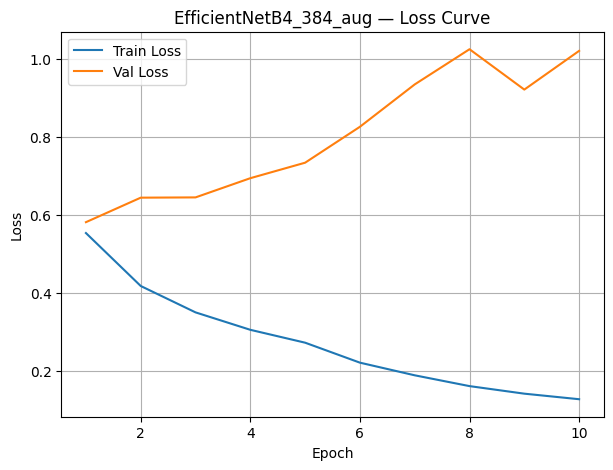

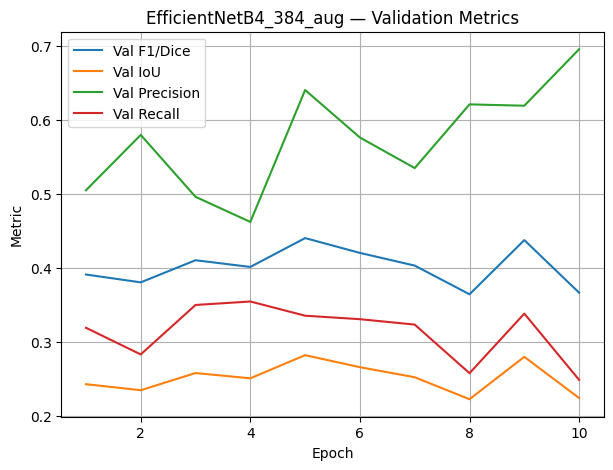

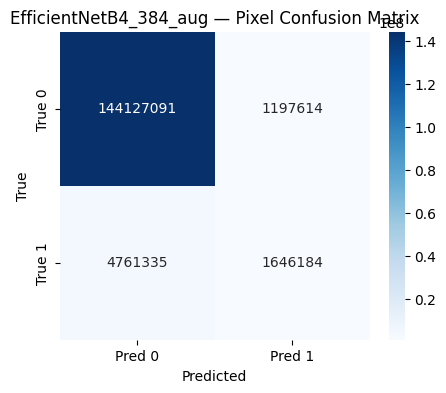

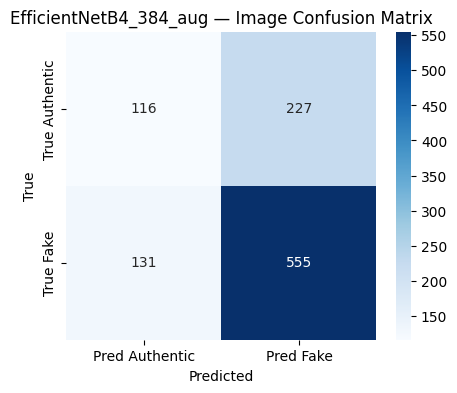

✓ Saved /kaggle/working/EfficientNetB4_384_aug_results.json

COPY-PASTE BACKUP:
{
  "model": "EfficientNetB4_384_aug",
  "pixel": {
    "accuracy": 0.9607272018895604,
    "precision": 0.578868119324929,
    "recall": 0.25691441570442436,
    "f1": 0.3558810016570997,
    "iou": 0.2164569640004978,
    "dice": 0.3558810059151575
  },
  "image": {
    "accuracy": 0.652089407191448,
    "precision": 0.7097186700767263,
    "recall": 0.8090379008746356,
    "f1": 0.7561307901907357
  },
  "params": 19412377,
  "size_mb": 74.05234146118164,
  "best_epoch": 5,
  "total_time": 2227.600969314575
}
✓ Checkpoint removed to save disk


In [6]:
# Cell 7 — EfficientNet-B4 training without augmentation

effnetb4_baseline = run_experiment(
    model_name='EfficientNetB4_384_aug',
    encoder_name='tu-tf_efficientnet_b4',
    augment=False,
    batch_size=8,         # try 8 if Kaggle GPU memory allows it
    pos_weight=3.0,      # change to POS_WEIGHT if recall is very low
    encoder_depth=5
)

In [7]:
# ============================================================
# Swin-Tiny — 384x384, No Augmentation + pos_weight = 3.0
# ============================================================

IMG_SIZE = 384

swin_tiny_384_noaug_posw_results = run_experiment(
    model_name='SwinTiny_384_noaug_posw3',
    encoder_name='tu-swin_tiny_patch4_window7_224',
    augment=False,
    batch_size=8,
    pos_weight=3.0,
    encoder_depth=5
)

experiment_summaries.append(swin_tiny_384_noaug_posw_results)


TRAINING: SwinTiny_384_noaug_posw3
Encoder: tu-swin_tiny_patch4_window7_224
Config: 384x384, augmentation=False, pos_weight=3.0
Batch size: 8
Building datasets | augmentation=False | batch_size=8
  training: 7559 total (5459 forged, 2100 authentic)
    fake files found: 5459 | masks found: 4200 | unmatched fakes: 0
  validation: 1023 total (682 forged, 341 authentic)
    fake files found: 682 | masks found: 682 | unmatched fakes: 0
  testing: 1029 total (686 forged, 343 authentic)
    fake files found: 686 | masks found: 686 | unmatched fakes: 0


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Parameters: 31,627,979
Trainable: 31,627,979
Estimated fp32 model size: 120.7 MB


AssertionError: Input height (384) doesn't match model (224).